<a href="https://colab.research.google.com/github/DanielSammaritani/Simple_Trading_Strategy/blob/main/Mean_Reversion_with_rsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The mean reversion strategies are strategy based on the idea that prices of a certain assests will return to their mean.
I used the RSI (Relative Strenght Indicator) to observe if the assests were oversold or overbought within the 70/30 parameters.



Downloaded the libraries and all the data form the tickers of 11 different ETFs, each one representing a specific sector

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
pd.set_option("display.max_columns", None)

tickers = [
    "XLK",   # Information Technology
    "XLF",   # Financials
    "XLV",   # Health Care
    "XLY",   # Consumer Discretionary
    "XLC",   # Communication Services
    "XLI",   # Industrials
    "XLP",   # Consumer Staples
    "XLE",   # Energy
    "XLU",   # Utilities
    "XLRE",  # Real Estate
    "XLB"    # Materials
]
data = yf.download(tickers, start ="2020-01-01")
data.dropna(inplace=True)
print(data)

/tmp/ipykernel_491/3040376686.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start ="2020-01-01")
[*********************100%***********************]  11 of 11 completed


Price           Close                                                \
Ticker            XLB         XLC        XLE        XLF         XLI   
Date                                                                  
2020-01-02  26.665550   50.919640  23.188854  27.546474   74.966118   
2020-01-03  26.235031   50.591187  23.119955  27.253994   74.821617   
2020-01-06  26.120815   51.266865  23.299860  27.236269   74.848686   
2020-01-07  26.090065   51.332554  23.238617  27.059010   74.695160   
2020-01-08  26.182316   51.698547  22.855835  27.236269   74.948029   
...               ...         ...        ...        ...         ...   
2026-08-28  53.180000  112.989998  62.680000  58.099998  177.139999   
2026-08-31  52.689999  111.459999  63.959999  57.709999  175.130005   
2026-09-01  52.070000  110.879997  64.769997  57.200001  172.729996   
2026-09-02  52.950001  112.419998  65.099998  57.660000  172.779999   
2026-09-03  52.619999  113.379997  64.620003  58.560001  174.559998   

Price

We use exponential mean of the 14 past days

In [ ]:
Log_ret = np.log(data["Close"]/data["Close"].shift(1))
gain = Log_ret.clip(lower = 0)
losses = -Log_ret.clip(upper = 0)
#define the strategy
Avg_gain_mean = gain.ewm(span = 14, adjust= False).mean()
Avg_losses_mean = losses.ewm(span = 14, adjust=False).mean()


Ticker            XLB         XLC        XLE        XLF         XLI  \
Date                                                                  
2020-01-02  26.665550   50.919640  23.188854  27.546474   74.966118   
2020-01-03  26.235031   50.591187  23.119955  27.253994   74.821617   
2020-01-06  26.120815   51.266865  23.299860  27.236269   74.848686   
2020-01-07  26.090065   51.332554  23.238617  27.059010   74.695160   
2020-01-08  26.182316   51.698547  22.855835  27.236269   74.948029   
...               ...         ...        ...        ...         ...   
2026-08-28  53.180000  112.989998  62.680000  58.099998  177.139999   
2026-08-31  52.689999  111.459999  63.959999  57.709999  175.130005   
2026-09-01  52.070000  110.879997  64.769997  57.200001  172.729996   
2026-09-02  52.950001  112.419998  65.099998  57.660000  172.779999   
2026-09-03  52.619999  113.379997  64.620003  58.560001  174.559998   

Ticker             XLK        XLP       XLRE        XLU         XLV  \
Date 

The RSI strategy

In [ ]:
#RSI Calculus
RS = Avg_gain_mean / Avg_losses_mean
RSI = 100-(100/(1+RS))
print(RSI)

Ticker            XLB        XLC        XLE        XLF        XLI        XLK  \
Date                                                                           
2020-01-02        NaN        NaN        NaN        NaN        NaN        NaN   
2020-01-03   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
2020-01-06   0.000000  23.978061  28.609879   0.000000   2.803380   3.136503   
2020-01-07   0.000000  25.955274  25.726225   0.000000   2.368491   3.116018   
2020-01-08   4.043326  36.524165  14.837116  10.077576  24.586972  18.278820   
...               ...        ...        ...        ...        ...        ...   
2026-08-28  56.221694  59.213500  59.639413  56.737647  28.934929  53.680035   
2026-08-31  45.694655  48.219544  70.715145  47.674870  23.415065  55.905090   
2026-09-01  35.803473  44.565961  75.537136  38.357688  18.492953  46.712417   
2026-09-02  52.574607  54.973312  77.280279  48.779904  18.905540  46.587840   
2026-09-03  47.260250  60.277926  69.016

As said before, we utilize the Rsi's signal, if the Indicator is > 70, it means that the assests is overbought, while if is < 30, it means that it is underbought

In [ ]:
signal = pd.DataFrame(np.select([RSI>70,RSI<30],[-1,1]), index = RSI.index, columns=RSI.columns)
print(signal)

Ticker      XLB  XLC  XLE  XLF  XLI  XLK  XLP  XLRE  XLU  XLV  XLY
Date                                                              
2020-01-02    0    0    0    0    0    0    0     0    0    0    0
2020-01-03    1    1    1    1    1    1    1    -1   -1    1    1
2020-01-06    1    1    1    1    1    1    1    -1   -1    1    1
2020-01-07    1    1    1    1    1    1    1    -1   -1    1    1
2020-01-08    1    0    1    1    1    1    1    -1   -1    1    1
...         ...  ...  ...  ...  ...  ...  ...   ...  ...  ...  ...
2026-08-28    0    0    0    0    1    0    0     0    0    0    0
2026-08-31    0    0   -1    0    1    0    0     1    1    0    0
2026-09-01    0    0   -1    0    1    0    0     1    0    0    0
2026-09-02    0    0   -1    0    1    0    0     1    0    0    0
2026-09-03    0    0    0    0    0    0    0     0    0    0    0

[1677 rows x 11 columns]


In [ ]:
strat = signal.shift(1)*Log_ret
print(strat.sum())

Ticker
XLB     0.516011
XLC     0.671191
XLE    -0.317119
XLF     0.345161
XLI     0.163218
XLK     0.629086
XLP     0.337660
XLRE    0.025991
XLU    -0.091127
XLV     0.355583
XLY     0.562489
dtype: float64


We print all the metrics and put them in a dataFrame

In [ ]:
#METRICS
#-Cumulative Returns
Cum_return_strat = np.exp(strat.sum())-1
print(Cum_return_strat)
Cum_return_bh = np.exp(Log_ret.sum())-1
print(Cum_return_bh)
#-Sharpe Ratio strat
annualized_growth_strat = np.exp(strat.mean()*252)-1
annualized_risk_free_rate =np.exp(0.04244)-1
annualized_volatility = strat.std() * np.sqrt(252)
Sharpe_strat = (annualized_growth_strat-annualized_risk_free_rate)/annualized_volatility
#-Sharpe Ratio LDO
annualized_growth_bh = np.exp((Log_ret.mean())*252)-1
annualized_volatility_bh = Log_ret.std() * np.sqrt(252)
Sharpe_bh = (annualized_growth_bh-annualized_risk_free_rate)/annualized_volatility_bh
print(Sharpe_strat)
print(Sharpe_bh)
#MAX drawdown strategy
cum_log_ret = strat.cumsum()
val = np.exp(cum_log_ret)
d_max = val.cummax()
d = (d_max-val)/d_max
print(d.max())
#max drawdown bh
cum_log_ret_bh= Log_ret.cumsum()
val_bh = np.exp(cum_log_ret_bh)
d_max_bh = val_bh.cummax()
d_bh = (d_max_bh - val_bh)/d_max_bh
print(d_bh.max())

Ticker
XLB     0.675332
XLC     0.956566
XLE    -0.271756
XLF     0.412217
XLI     0.177293
XLK     0.875894
XLP     0.401664
XLRE    0.026331
XLU    -0.087099
XLV     0.427012
XLY     0.755035
dtype: float64
Ticker
XLB     0.973333
XLC     1.226646
XLE     1.786684
XLF     1.125862
XLI     1.328519
XLK     3.203527
XLP     0.620149
XLRE    0.439248
XLU     0.648768
XLV     0.885294
XLY     0.939851
dtype: float64
Ticker
XLB     0.315201
XLC     0.556036
XLE    -0.407200
XLF     0.072339
XLI    -0.148174
XLK     0.406706
XLP     0.113971
XLRE   -0.333800
XLU    -0.465185
XLV     0.135712
XLY     0.360792
dtype: float64
Ticker
XLB     0.279391
XLC     0.369196
XLE     0.362292
XLF     0.312723
XLI     0.414406
XLK     0.705988
XLP     0.194545
XLRE    0.055466
XLU     0.159756
XLV     0.314022
XLY     0.242382
dtype: float64
Ticker
XLB     0.118281
XLC     0.109728
XLE     0.565113
XLF     0.185592
XLI     0.140283
XLK     0.258477
XLP     0.091285
XLRE    0.319713
XLU     0.226597
XLV 

In [ ]:

dashboard = pd.DataFrame(
     {"strat-result" : Cum_return_strat,
        "b-h result" : Cum_return_bh,
        "strat-sharpe" : Sharpe_strat,
        "b-h sharpe" : Sharpe_bh,
        "strat max-drawdown" : d.max(),
        "b-h max-drawdown" : d_bh.max()
    }

)

print(dashboard)

        strat-result  b-h result  strat-sharpe  b-h sharpe  \
Ticker                                                       
XLB         0.675332    0.973333      0.315201    0.279391   
XLC         0.956566    1.226646      0.556036    0.369196   
XLE        -0.271756    1.786684     -0.407200    0.362292   
XLF         0.412217    1.125862      0.072339    0.312723   
XLI         0.177293    1.328519     -0.148174    0.414406   
XLK         0.875894    3.203527      0.406706    0.705988   
XLP         0.401664    0.620149      0.113971    0.194545   
XLRE        0.026331    0.439248     -0.333800    0.055466   
XLU        -0.087099    0.648768     -0.465185    0.159756   
XLV         0.427012    0.885294      0.135712    0.314022   
XLY         0.755035    0.939851      0.360792    0.242382   

        strat max-drawdown  b-h max-drawdown  
Ticker                                        
XLB               0.118281          0.368560  
XLC               0.109728          0.466536  
XLE  

Plot the results of the strategy of each sector

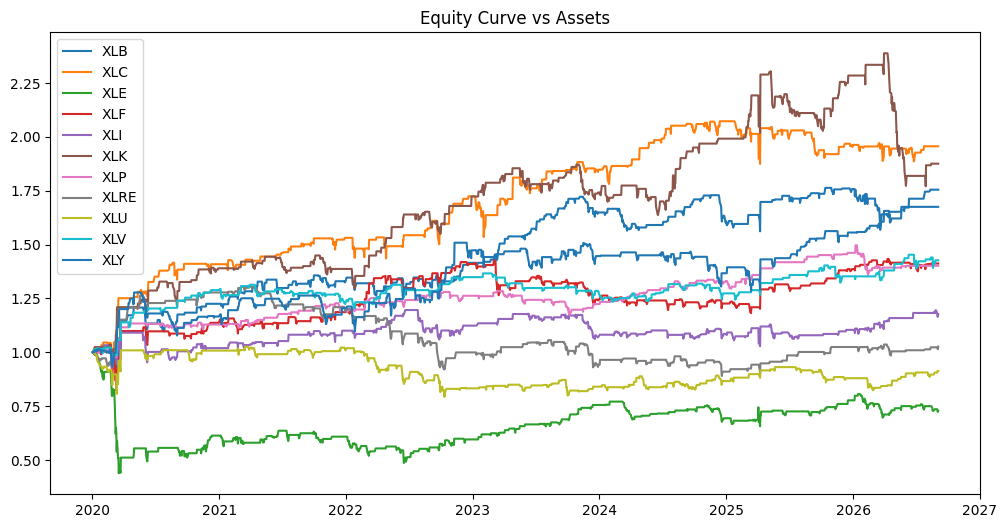

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(val)
plt.title("Equity Curve")
plt.legend(RSI.columns)
plt.show()

As we can see on the graph, the strategy performed in terms of returns, but the buy & hold strategy would outperform the Mean Reversion with RSI in 11 cases out of 11. This means that this type of strategy, during a bull market, tend to generate false or delayed signals.
But the other indicators (Sharpe - Max Drawdown) are better compared the buy & hold: The Sharpe of the Strategy is better 3 times out of 11, while the max drawdown of the strategy is always inferior compared to the classical buy & hold
This strategy could be better using TPs or SLs, but i am still looking towards it



